<a href="https://colab.research.google.com/github/bismarxx/analisis-datos/blob/main/71388365.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
url = 'https://raw.githubusercontent.com/bismarxx/analisis-datos/main/glpi%20(2).csv'

df = pd.read_csv(url, sep=';')

# ELiminar datos que no se usaran, año 2022, mes de mayo del 2026
df['Fecha de apertura'] = pd.to_datetime(df['Fecha de apertura'], format='%d-%m-%Y %H:%M', errors='coerce')
df = df[df['Fecha de apertura'].dt.year >= 2025]
df = df[~((df['Fecha de apertura'].dt.year == 2026) & (df['Fecha de apertura'].dt.month == 5))]
df.head()

,ID,Título,Tipo,Fecha de apertura,Solicitante - Solicitante,Categoría,Ubicación,Asignado a - Técnico,Fecha de resolución,Soluciones - Soluciones,Última modificación,Fecha de cierre,Unnamed: 12
1,"67,448",PAS-2026-043 PASE A PRODUCCIÓN ROFBOTIA ADMIN,Solicitud,2026-04-19 13:06:00,Lenin Bismarx Mendoza Mamani,Software,PCM - Piñeiro > Secretaría General - SG > Secr...,Roland Corasi Limache <br>Raul Oscar Mitma Siv...,05-05-2026 08:39,Se procedió en realizar el pase correctivo el ...,06-05-2026 08:17,06-05-2026 08:17,NaN
2,"67,734",PAS-2026-045 PASE A PRODUCCIÓN SUT,Solicitud,2026-04-23 17:25:00,Lenin Bismarx Mendoza Mamani,Sistema > Sistema Único de Tramites - SUT > Pa...,PCM - Piñeiro > Secretaría General - SG > Secr...,Roland Corasi Limache <br>Raul Oscar Mitma Siv...,27-04-2026 12:36,Se ejecutó el pase a producción de la base de ...,04-05-2026 12:22,04-05-2026 12:22,NaN
3,"67,429",PAS-2026-044 PASE A PRODUCCIÓN SGD,Solicitud,2026-04-17 16:49:00,Lenin Bismarx Mendoza Mamani,Sistema de Gestión Documental SGD > Configuración,PCM - Piñeiro > Secretaría General - SG > Secr...,Emelson Alex Chire Hernandez,19-04-2026 00:09,Se ejecutó el pase a producción de la base de ...,21-04-2026 15:43,21-04-2026 15:43,NaN
4,"67,432",PAS-2026-042 PASE A PRODUCCIÓN ROFBOTIA,Solicitud,2026-04-17 18:24:00,Lenin Bismarx Mendoza Mamani,Software,PCM - Piñeiro > Secretaría General - SG > Secr...,Roland Corasi Limache <br>Fernando Augusto Moo...,20-04-2026 19:18,Se ejecutó el pase a producción de la base de ...,21-04-2026 15:41,21-04-2026 15:41,NaN
5,"66,953",PAS-2026-040 PASE CORRECTIVO SISECON,Solicitud,2026-04-09 16:26:00,Lenin Bismarx Mendoza Mamani,Sistema de Evaluación para Condecoración - SIS...,PCM - Piñeiro > Secretaría General - SG > Secr...,Roland Corasi Limache <br>Fernando Augusto Moo...,15-04-2026 11:26,El pase a producción fue realizado el 09/04,15-04-2026 17:16,15-04-2026 17:16,NaN


In [ ]:
def clasificar_pase(titulo):
    if pd.isna(titulo):
        return 0

    titulo_lower = str(titulo).lower()

    if 'producción' in titulo_lower or 'produccion' in titulo_lower:
        return 1
    elif 'correctivo' in titulo_lower:
        return 2
    elif 'emergencia' in titulo_lower:
        return 3
    elif 'incidencia' in titulo_lower or 'incidente' in titulo_lower:
        return 4
    else:
        return 0

df['Clasificación'] = df['Título'].apply(clasificar_pase)

df[['Título', 'Clasificación']].head(15)

,Título,Clasificación
1,PAS-2026-043 PASE A PRODUCCIÓN ROFBOTIA ADMIN,1
2,PAS-2026-045 PASE A PRODUCCIÓN SUT,1
3,PAS-2026-044 PASE A PRODUCCIÓN SGD,1
4,PAS-2026-042 PASE A PRODUCCIÓN ROFBOTIA,1
5,PAS-2026-040 PASE CORRECTIVO SISECON,2
6,PAS-2026-041 PASE CORRECTIVO OPMR,2
7,PAS-2026-039 PASE CORRECTIVO SCRAN,2
8,PAS-2026-036 PASE A PRODUCCIÓN SIGAR,1
9,PAS-2026-037 PASE A PRODUCCIÓN SISNTC,1
10,PAS-2026-038 PASE A PRODUCCIÓN MPD,1


/tmp/ipykernel_1579/1819003007.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cantidad', y='Tipo de Pase', data=resumen, palette='viridis', ax=ax1)


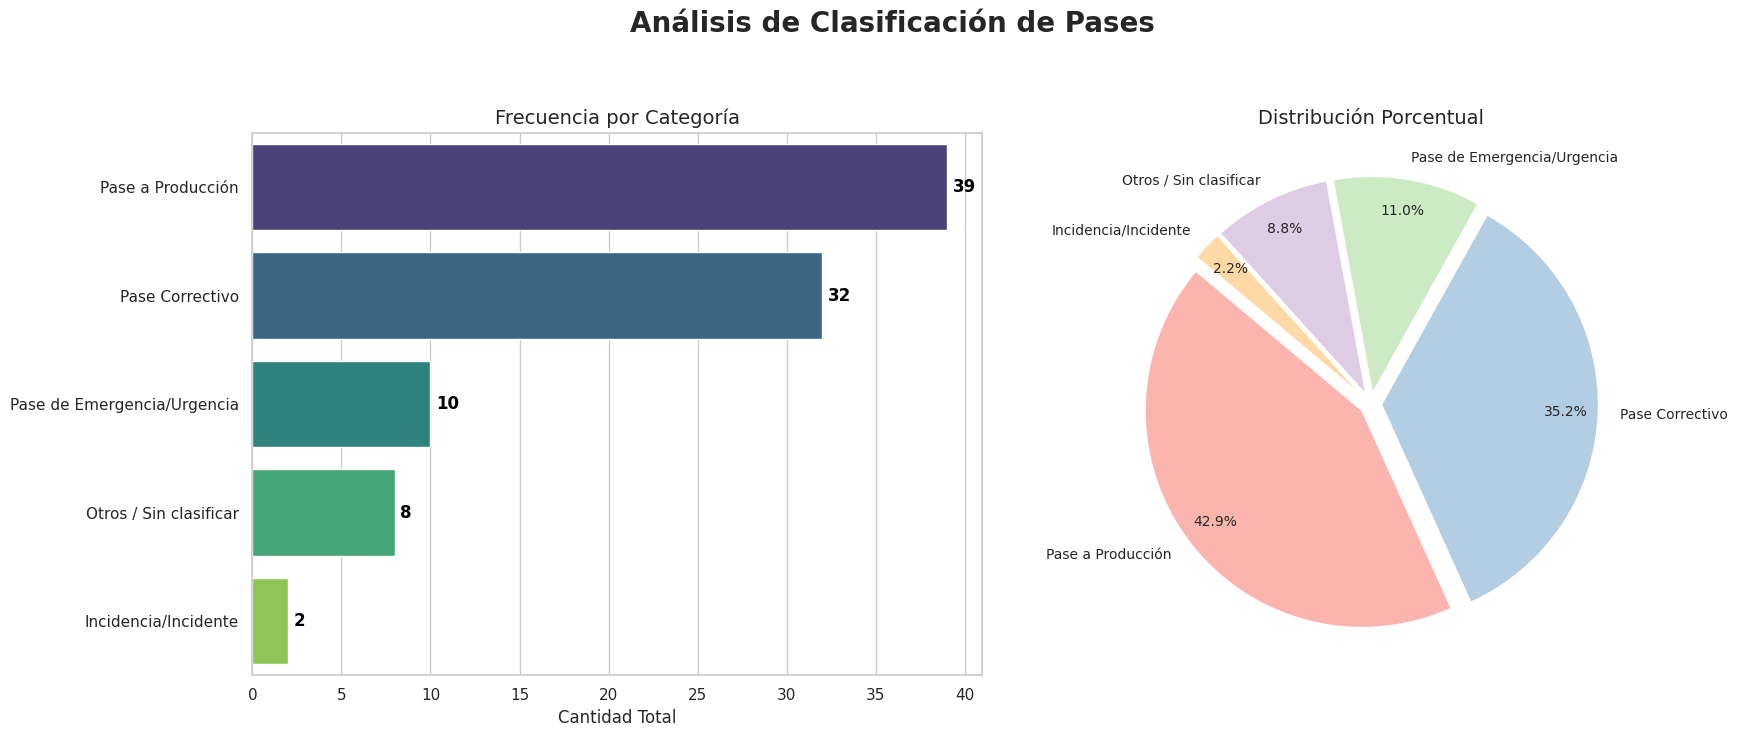

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

nombres_clases = {
    1: 'Pase a Producción',
    2: 'Pase Correctivo',
    3: 'Pase de Emergencia/Urgencia',
    4: 'Incidencia/Incidente',
    0: 'Otros / Sin clasificar'
}

# Mapeamos y contamos en un solo paso, luego ordenamos por cantidad
resumen = (df['Clasificación']
           .map(nombres_clases)
           .value_counts()
           .reset_index())

resumen.columns = ['Tipo de Pase', 'Cantidad']
resumen = resumen.sort_values(by='Cantidad', ascending=False)

# CONFIGURACIÓN VISUAL (SUBPLOTS)
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Análisis de Clasificación de Pases', fontsize=20, fontweight='bold', y=1.05)

# --- GRÁFICO DE BARRAS (Izquierda) ---
sns.barplot(x='Cantidad', y='Tipo de Pase', data=resumen, palette='viridis', ax=ax1)
ax1.set_title('Frecuencia por Categoría', fontsize=14)
ax1.set_xlabel('Cantidad Total', fontsize=12)
ax1.set_ylabel('', fontsize=12) # Eliminamos el label de Y porque ya se ven los nombres

# Añadir etiquetas de datos al final de cada barra
for i, v in enumerate(resumen['Cantidad']):
    ax1.text(v + 0.3, i, str(int(v)), color='black', va='center', fontweight='bold')

# --- GRÁFICO DE PASTEL (Derecha) ---
colores = sns.color_palette('Pastel1')
ax2.pie(
    resumen['Cantidad'],
    labels=resumen['Tipo de Pase'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colores,
    explode=[0.05] * len(resumen),
    pctdistance=0.85,
    textprops={'fontsize': 10}
)
ax2.set_title('Distribución Porcentual', fontsize=14)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1579/434171149.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mapa_datos = df.groupby(['Día de semana', 'Hora']).size().unstack(fill_value=0)


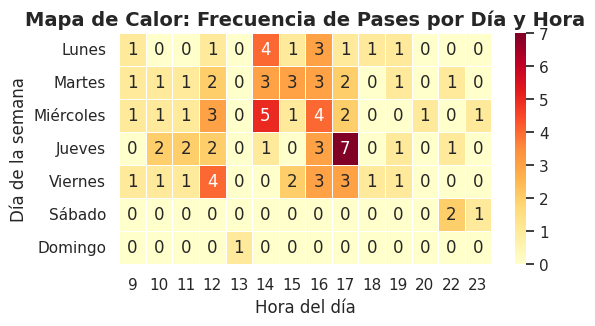

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df['Fecha de apertura'] = pd.to_datetime(df['Fecha de apertura'], format='%d-%m-%Y %H:%M', errors='coerce')

dias_espanol = {'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
                'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado', 'Sunday': 'Domingo'}

df['Día de semana'] = df['Fecha de apertura'].dt.day_name().map(dias_espanol)
df['Hora'] = df['Fecha de apertura'].dt.hour

# Ordenamos los días lógicamente para el gráfico
orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
df['Día de semana'] = pd.Categorical(df['Día de semana'], categories=orden_dias, ordered=True)

# Creamos una tabla dinámica que cuente cuántos pases hay por cada día y hora
mapa_datos = df.groupby(['Día de semana', 'Hora']).size().unstack(fill_value=0)

plt.figure(figsize=(6, 3)) # Tamaño del gráfico
sns.heatmap(mapa_datos, cmap='YlOrRd', annot=True, fmt='d', linewidths=.5)

plt.title('Mapa de Calor: Frecuencia de Pases por Día y Hora', fontsize=14, fontweight='bold')
plt.xlabel('Hora del día', fontsize=12)
plt.ylabel('Día de la semana', fontsize=12)

plt.show()

/tmp/ipykernel_1579/2046970948.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mapa_semana = df.groupby(['Día de semana', 'Semana del año']).size().unstack(fill_value=0)


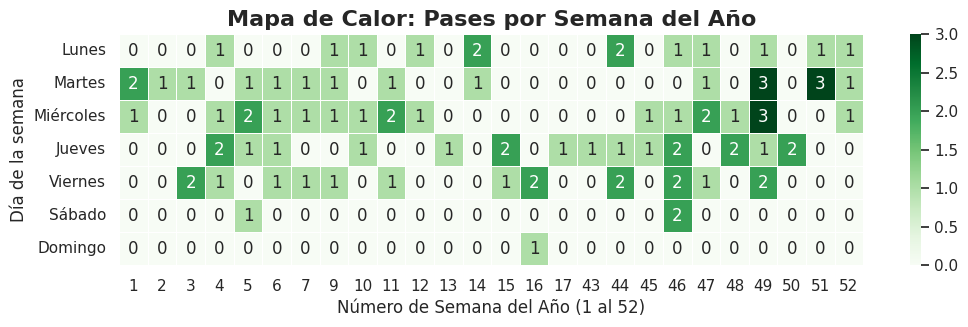

In [ ]:
df['Fecha de apertura'] = pd.to_datetime(df['Fecha de apertura'], format='%d-%m-%Y %H:%M', errors='coerce')
df = df.dropna(subset=['Fecha de apertura'])

#Extraemos el Día de la semana y lo traducimos
dias_espanol = {'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
                'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado', 'Sunday': 'Domingo'}
df['Día de semana'] = df['Fecha de apertura'].dt.day_name().map(dias_espanol)

# Extraemos el número de la semana del año (1 al 52)
df['Semana del año'] = df['Fecha de apertura'].dt.isocalendar().week

# Ordenamos los días de Lunes a Domingo para que el gráfico tenga sentido
orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
df['Día de semana'] = pd.Categorical(df['Día de semana'], categories=orden_dias, ordered=True)

# Creamos la tabla cruzando Día de semana (filas) y Semana del año (columnas)
mapa_semana = df.groupby(['Día de semana', 'Semana del año']).size().unstack(fill_value=0)

# Dibujamos el Mapa en tono verde
plt.figure(figsize=(12, 3))
sns.heatmap(mapa_semana, cmap='Greens', annot=True, fmt='d', linewidths=.5)

plt.title('Mapa de Calor: Pases por Semana del Año', fontsize=16, fontweight='bold')
plt.xlabel('Número de Semana del Año (1 al 52)', fontsize=12)
plt.ylabel('Día de la semana', fontsize=12)

plt.show()

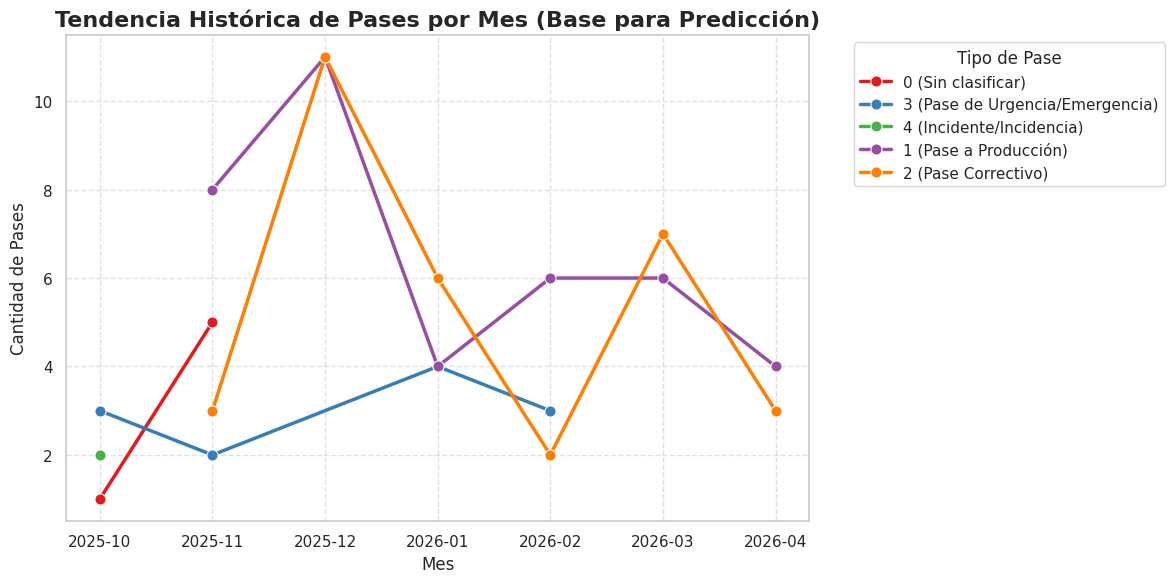

In [ ]:
def clasificar_pase2(titulo):
    if pd.isna(titulo): return 'Otros (Sin clasificar)'

    t = str(titulo).lower()
    if 'producción' in t or 'produccion' in t:
        return '1 (Pase a Producción)'
    elif 'correctivo' in t:
        return '2 (Pase Correctivo)'
    elif 'emergencia' in t or 'urgencia' in t:
        return '3 (Pase de Urgencia/Emergencia)'
    elif 'incidencia' in t or 'incidente' in t:
        return '4 (Incidente/Incidencia)'
    else:
        return '0 (Sin clasificar)'

df['Tipo_Pase'] = df['Título'].apply(clasificar_pase2)

df['Año-Mes'] = df['Fecha de apertura'].dt.strftime('%Y-%m')

# Agrupar los datos por Mes y Tipo de Pase
tendencia = df.groupby(['Año-Mes', 'Tipo_Pase']).size().reset_index(name='Cantidad')

# CREAR EL GRÁFICO DE LÍNEAS
plt.figure(figsize=(12, 6))

# Dibujamos las líneas
sns.lineplot(data=tendencia, x='Año-Mes', y='Cantidad', hue='Tipo_Pase',
             marker='o', linewidth=2.5, markersize=8, palette='Set1')

plt.title('Tendencia Histórica de Pases por Mes (Base para Predicción)', fontsize=16, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Cantidad de Pases', fontsize=12)

# Colocamos la leyenda fuera del gráfico
plt.legend(title='Tipo de Pase', bbox_to_anchor=(1.05, 1), loc='upper left')

# Agregamos una cuadrícula de fondo
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

INFO:prophet:n_changepoints greater than number of observations. Using 20.


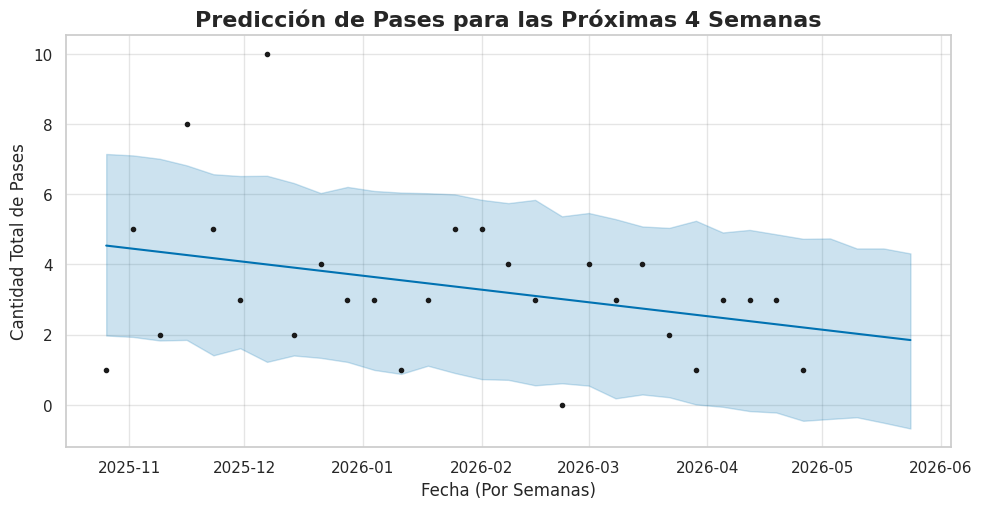


--- NÚMEROS ESPERADOS PARA LAS PRÓXIMAS 4 SEMANAS ---
Fecha de la Semana  Predicción Exacta  Mínimo Esperado  Máximo Esperado
        2026-05-03                2.0             -0.0              5.0
        2026-05-10                2.0             -0.0              4.0
        2026-05-17                2.0             -1.0              4.0
        2026-05-24                2.0             -1.0              4.0


In [ ]:
import matplotlib.pyplot as plt
from prophet import Prophet

df['Fecha de apertura'] = pd.to_datetime(df['Fecha de apertura'], format='%d-%m-%Y %H:%M', errors='coerce')
df = df.dropna(subset=['Fecha de apertura'])
df = df[df['Fecha de apertura'].dt.year >= 2025]
df = df[~((df['Fecha de apertura'].dt.year == 2026) & (df['Fecha de apertura'].dt.month == 5))]

# PREPARAMOS LOS DATOS PARA PROPHET
# Agrupamos contando el total de pases POR SEMANA
pred_df = df.set_index('Fecha de apertura').resample('W').size().reset_index()

# Usamos las columnas se llamen 'ds' (fechas) y 'y' (valores)
pred_df.columns = ['ds', 'y']

# ENTRENAMOS EL MODELO (La máquina aprende)
modelo = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False)
modelo.fit(pred_df)

# creeamos un calendario con las próximas 4 semanas hacia el futuro
futuro = modelo.make_future_dataframe(periods=4, freq='W')

# HACEMOS LA PREDICCIÓN
prediccion = modelo.predict(futuro)

# DIBUJAMOS EL RESULTADO
fig = modelo.plot(prediccion, figsize=(10, 5))
plt.title('Predicción de Pases para las Próximas 4 Semanas', fontsize=16, fontweight='bold')
plt.xlabel('Fecha (Por Semanas)', fontsize=12)
plt.ylabel('Cantidad Total de Pases', fontsize=12)

plt.show()

# Mostramos los números exactos predichos para las próximas 4 semanas
print("\n--- NÚMEROS ESPERADOS PARA LAS PRÓXIMAS 4 SEMANAS ---")

# Filtramos solo las últimas 4 filas que son el futuro
resultado_futuro = prediccion[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(4)
resultado_futuro.columns = ['Fecha de la Semana', 'Predicción Exacta', 'Mínimo Esperado', 'Máximo Esperado']

resultado_futuro = resultado_futuro.round(0)
print(resultado_futuro.to_string(index=False))

INFO:prophet:n_changepoints greater than number of observations. Using 18.


Entrenando la IA para cada tipo de pase... Esto tomará unos segundos.



INFO:prophet:n_changepoints greater than number of observations. Using 16.
INFO:prophet:n_changepoints greater than number of observations. Using 12.


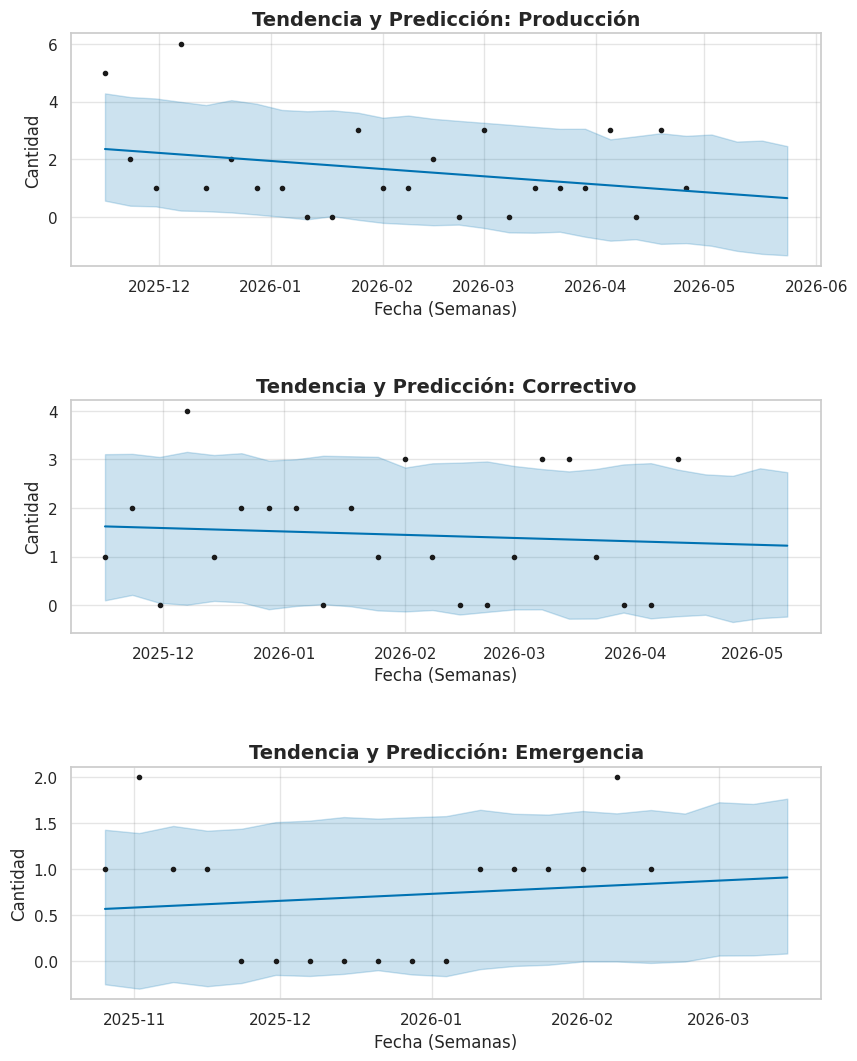


  PREDICCIÓN EXACTA PARA LAS PRÓXIMAS 4 SEMANAS  
Tipo        Correctivo  Emergencia  Producción
ds                                            
2026-02-22         NaN         1.0         NaN
2026-03-01         NaN         1.0         NaN
2026-03-08         NaN         1.0         NaN
2026-03-15         NaN         1.0         NaN
2026-04-19         1.0         NaN         NaN
2026-04-26         1.0         NaN         NaN
2026-05-03         1.0         NaN         1.0
2026-05-10         1.0         NaN         1.0
2026-05-17         NaN         NaN         1.0
2026-05-24         NaN         NaN         1.0


In [ ]:
df['Fecha de apertura'] = pd.to_datetime(df['Fecha de apertura'], format='%d-%m-%Y %H:%M', errors='coerce')
df = df.dropna(subset=['Fecha de apertura'])
df = df[df['Fecha de apertura'].dt.year >= 2025]
df = df[~((df['Fecha de apertura'].dt.year == 2026) & (df['Fecha de apertura'].dt.month == 5))]

def clasificar_pase3(titulo):
    if pd.isna(titulo): return 'Otros'
    t = str(titulo).lower()
    if 'producción' in t or 'produccion' in t: return 'Producción'
    elif 'correctivo' in t: return 'Correctivo'
    elif 'emergencia' in t or 'urgencia' in t: return 'Emergencia'
    else: return 'Otros' # Agrupamos incidencias en Otros para simplificar la predicción

df['Tipo_Pase'] = df['Título'].apply(clasificar_pase3)

# DEFINIMOS QUÉ QUEREMOS PREDECIR
# Nos enfocaremos en los 3 más críticos para tu gestión
tipos_a_predecir = ['Producción', 'Correctivo', 'Emergencia']

# Aquí guardaremos los resultados finales
resultados_finales = pd.DataFrame()

# Preparamos un lienzo para dibujar los 3 gráficos
fig, axs = plt.subplots(len(tipos_a_predecir), 1, figsize=(10, 12))
fig.tight_layout(pad=6.0)

print("Entrenando la IA para cada tipo de pase... Esto tomará unos segundos.\n")

# ENTRENAMOS UN MODELO PARA CADA TIPO DE PASE
for i, tipo in enumerate(tipos_a_predecir):
    # Filtramos solo los datos de ese tipo específico
    df_tipo = df[df['Tipo_Pase'] == tipo]

    # Agrupamos por semana
    pred_df = df_tipo.set_index('Fecha de apertura').resample('W').size().reset_index()
    pred_df.columns = ['ds', 'y']

    # Entrenamos el modelo
    modelo = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False)
    modelo.fit(pred_df)

    # Predecimos 4 semanas
    futuro = modelo.make_future_dataframe(periods=4, freq='W')
    prediccion = modelo.predict(futuro)

    # Dibujamos su gráfico correspondiente
    modelo.plot(prediccion, ax=axs[i])
    axs[i].set_title(f'Tendencia y Predicción: {tipo}', fontsize=14, fontweight='bold')
    axs[i].set_xlabel('Fecha (Semanas)')
    axs[i].set_ylabel('Cantidad')

    # Extraemos solo el futuro y lo guardamos
    res_temp = prediccion[['ds', 'yhat']].tail(4).copy()
    res_temp['Tipo'] = tipo

    # Redondeamos los números y evitamos que salgan números negativos (no puedes tener -1 pases)
    res_temp['yhat'] = res_temp['yhat'].round(0).clip(lower=0)
    resultados_finales = pd.concat([resultados_finales, res_temp])

plt.show()


tabla_pivote = resultados_finales.pivot(index='ds', columns='Tipo', values='yhat')
tabla_pivote.index = tabla_pivote.index.strftime('%Y-%m-%d') # Formateamos la fecha

print("\n=======================================================")
print("  PREDICCIÓN PARA LAS PRÓXIMAS 4 SEMANAS  ")
print("=======================================================")
print(tabla_pivote)

In [ ]:
analisis_sesgo = pd.merge(pred_df, prediccion[['ds', 'yhat']], on='ds', how='inner')

# Calculamos el Error de cada semana: (Cantidad Real - Cantidad Predicha)
analisis_sesgo['Error'] = analisis_sesgo['y'] - analisis_sesgo['yhat']

# El SESGO es el promedio matemático de todos esos errores a lo largo de los meses
sesgo_total = analisis_sesgo['Error'].mean()

print("=========================================")
print(f"  SESGO DEL MODELO: {sesgo_total:.2f} pases")
print("=========================================\n")

# Interpretación automática
if sesgo_total > 0.5:
    print(f"Resultado: El modelo SUBESTIMA el trabajo.")
    print(f"Por lo general, ocurren {abs(sesgo_total):.2f} pases MÁS de los que el modelo predice.")
elif sesgo_total < -0.5:
    print(f"Resultado: El modelo SOBREESTIMA el trabajo.")
    print(f"Por lo general, ocurren {abs(sesgo_total):.2f} pases MENOS de los que el modelo predice.")
else:
    print("Resultado: El modelo está MUY BIEN CALIBRADO.")
    print("El margen de error sistemático es casi nulo (tiende a acertar el promedio general).")

# Opcional: Mostrar las semanas donde el modelo tuvo el error más grande (los peores sesgos puntuales)
print("\n--- Semanas con mayor diferencia entre la realidad y la predicción ---")
peores_errores = analisis_sesgo.copy()
peores_errores['Error Absoluto'] = peores_errores['Error'].abs()
peores_errores = peores_errores.sort_values('Error Absoluto', ascending=False).head(3)

peores_errores = peores_errores[['ds', 'y', 'yhat', 'Error']]
peores_errores.columns = ['Fecha', 'Pases Reales', 'Lo que predijo', 'Diferencia (Error)']
peores_errores['Lo que predijo'] = peores_errores['Lo que predijo'].round(1)
print(peores_errores.to_string(index=False))

  SESGO DEL MODELO: -0.00 pases

Resultado: El modelo está MUY BIEN CALIBRADO.
El margen de error sistemático es casi nulo (tiende a acertar el promedio general).

--- Semanas con mayor diferencia entre la realidad y la predicción ---
     Fecha  Pases Reales  Lo que predijo  Diferencia (Error)
2025-11-02             2             0.6            1.413765
2026-02-08             2             0.8            1.174249
2026-01-04             0             0.7           -0.740210
